# Content-Based Movie Recommendation System Using TF-IDF and Cosine Similarity

In [1]:
!pip install pandas

# Load dataset

In [2]:
import pandas as pd      
movies = pd.read_csv("/kaggle/input/datasets/abhikjha/movielens-100k/ml-latest-small/movies.csv")
movies = movies.fillna("")



# Clean titles

In [3]:

movies = movies.fillna("")
movies["combined"] = movies["title"] + " " + movies["genres"]
movies["combined"] = movies["combined"].str.replace(
    r"[^a-zA-Z0-9 ]", "", regex=True
).str.lower()
movies.head()

,movieId,title,genres,combined
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,toy story 1995 adventureanimationchildrencomed...
1,2,Jumanji (1995),Adventure|Children|Fantasy,jumanji 1995 adventurechildrenfantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,grumpier old men 1995 comedyromance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,waiting to exhale 1995 comedydramaromance
4,5,Father of the Bride Part II (1995),Comedy,father of the bride part ii 1995 comedy


In [4]:
!pip install scikit-learn

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Create TF-IDF matrix

In [6]:
tfidf = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf.fit_transform(movies["combined"])

In [7]:
count = CountVectorizer(stop_words="english")
count_matrix = count.fit_transform(movies["combined"])

# Recommendation Function

In [8]:
def recommend(title, matrix):
    title = title.lower()
    
  
    idx = movies[movies["title"].str.lower() == title].index
    
    if len(idx) == 0:
        return "Movie not found"
    
    idx = idx[0]
    
    similarity = cosine_similarity(matrix[idx], matrix).flatten()
    
    indices = similarity.argsort()[-10:][::-1]
    
    return movies.iloc[indices][["title", "genres"]]

In [9]:
recommend("Toy Story (1995)", tfidf_matrix)

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2355,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy
7355,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX
3595,"Toy, The (1982)",Comedy
6194,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy
4089,Toy Soldiers (1991),Action|Drama
3568,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy
6486,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy
8219,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy
1706,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy


# Evaluation (Precision@K)

In [10]:
def precision_at_k(recommended, relevant, k=5):
    recommended = recommended[:k]
    relevant = set(relevant)
    
    score = 0
    for movie in recommended:
        if movie in relevant:
            score += 1
            
    return score / k

In [11]:
test_movie = "Toy Story (1995)"

tfidf_results = recommend(test_movie, tfidf_matrix)["title"].values
count_results = recommend(test_movie, count_matrix)["title"].values

# simple relevant set
relevant_movies = [
    "Toy Story 2 (1999)",
    "Toy Story 3 (2010)"
]

tfidf_score = precision_at_k(tfidf_results, relevant_movies)
count_score = precision_at_k(count_results, relevant_movies)

print("TF-IDF:", tfidf_score)
print("Count:", count_score)

TF-IDF: 0.4
Count: 0.4


In [12]:
!pip install matplotlib

In [13]:
import matplotlib.pyplot as plt

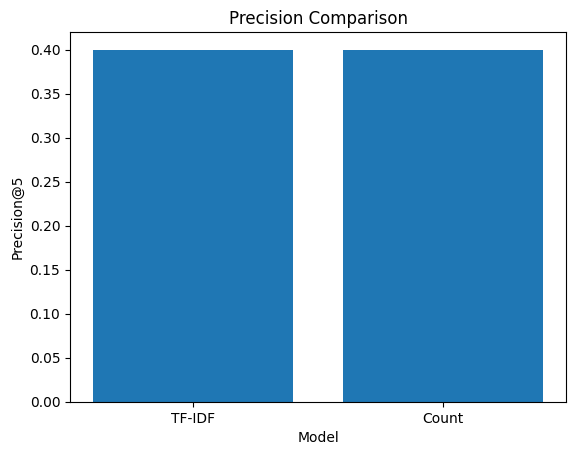

In [14]:
models = ["TF-IDF", "Count"]
scores = [tfidf_score, count_score]

plt.figure()
plt.bar(models, scores)

plt.title("Precision Comparison")
plt.xlabel("Model")
plt.ylabel("Precision@5")

plt.show()

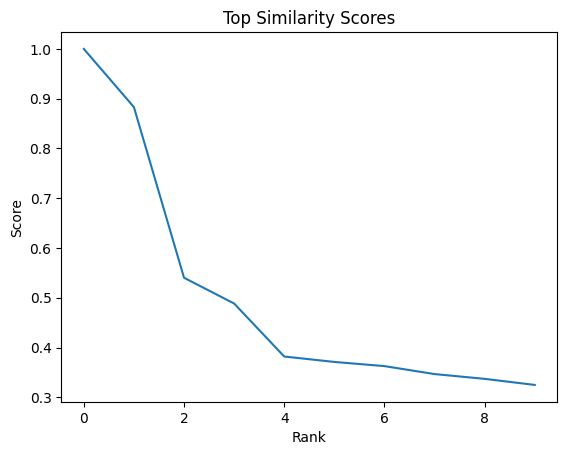

In [15]:
sim = cosine_similarity(tfidf_matrix[0], tfidf_matrix).flatten()
top_sim = sorted(sim, reverse=True)[:10]

plt.figure()
plt.plot(top_sim)

plt.title("Top Similarity Scores")
plt.xlabel("Rank")
plt.ylabel("Score")

plt.show()

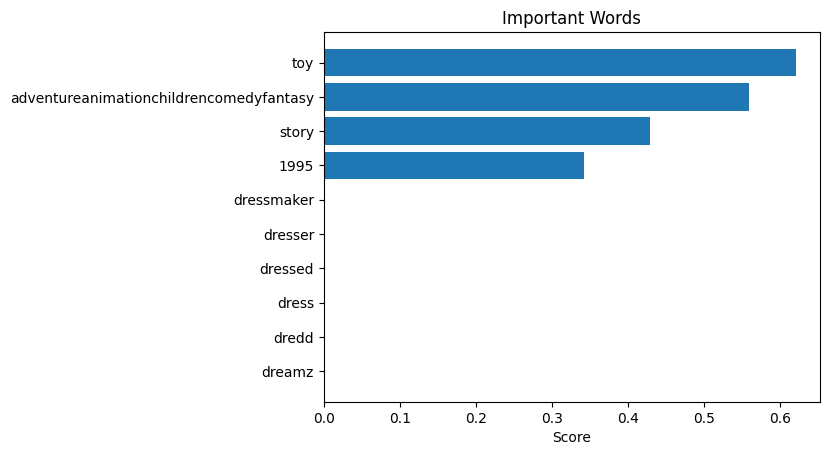

In [16]:
features = tfidf.get_feature_names_out()
values = tfidf_matrix[0].toarray().flatten()

top_idx = values.argsort()[-10:]
top_words = [features[i] for i in top_idx]
top_vals = values[top_idx]

plt.figure()
plt.barh(top_words, top_vals)

plt.title("Important Words")
plt.xlabel("Score")

plt.show()